In [ ]:
import pandas as pd

data = {
    "Country": ["France", "Spain", "Germany", "Spain", "Germany"],
    "Age": [44, 27, 30, 38, 40],
    "Salary": [72000, 48000, None, 61000, 79000],
    "Purchased": ["Yes", "No", "Yes", "No", "Yes"]
}

df = pd.DataFrame(data)
df.to_csv("sample.csv", index=False)

print("sample.csv created successfully!")
df


sample.csv created successfully!


,Country,Age,Salary,Purchased
0,France,44,72000.0,Yes
1,Spain,27,48000.0,No
2,Germany,30,NaN,Yes
3,Spain,38,61000.0,No
4,Germany,40,79000.0,Yes


In [ ]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Load dataset
data = pd.read_csv("sample.csv")
X = data.iloc[:, :-1].values
Y = data.iloc[:, -1].values

# Handle missing values
imputer = SimpleImputer(strategy='mean')
X[:, 1:3] = imputer.fit_transform(X[:, 1:3])

# One-hot encode categorical column
ct = ColumnTransformer([("encoder", OneHotEncoder(), [0])], remainder='passthrough')
X = ct.fit_transform(X)

# Encode dependent variable
le = LabelEncoder()
Y = le.fit_transform(Y)

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

# Feature scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Load dataset
data = pd.read_csv("sample.csv")
print("Original Dataset:\n", data, "\n")

X = data.iloc[:, :-1].values
Y = data.iloc[:, -1].values

print("Initial X:\n", X, "\n")
print("Initial Y:\n", Y, "\n")

# Handle missing values
imputer = SimpleImputer(strategy='mean')
X[:, 1:3] = imputer.fit_transform(X[:, 1:3])
print("After Handling Missing Values:\n", X, "\n")

# One-hot encode Category Column
ct = ColumnTransformer([("encoder", OneHotEncoder(), [0])], remainder='passthrough')
X = ct.fit_transform(X)
print("After One-Hot Encoding:\n", X, "\n")

# Encode Y Convert Yes/No into 0/1
le = LabelEncoder()
Y = le.fit_transform(Y)
print("Label Encoded Y:\n", Y, "\n")

# Train-Test Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

print("Training X:\n", X_train, "\n")
print("Testing X:\n", X_test, "\n")

# Feature Scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

print("Scaled Training X:\n", X_train, "\n")
print("Scaled Testing X:\n", X_test, "\n")


Original Dataset:
    Country  Age   Salary Purchased
0   France   44  72000.0       Yes
1    Spain   27  48000.0        No
2  Germany   30      NaN       Yes
3    Spain   38  61000.0        No
4  Germany   40  79000.0       Yes 

Initial X:
 [['France' 44 72000.0]
 ['Spain' 27 48000.0]
 ['Germany' 30 nan]
 ['Spain' 38 61000.0]
 ['Germany' 40 79000.0]] 

Initial Y:
 ['Yes' 'No' 'Yes' 'No' 'Yes'] 

After Handling Missing Values:
 [['France' 44.0 72000.0]
 ['Spain' 27.0 48000.0]
 ['Germany' 30.0 65000.0]
 ['Spain' 38.0 61000.0]
 ['Germany' 40.0 79000.0]] 

After One-Hot Encoding:
 [[1.0 0.0 0.0 44.0 72000.0]
 [0.0 0.0 1.0 27.0 48000.0]
 [0.0 1.0 0.0 30.0 65000.0]
 [0.0 0.0 1.0 38.0 61000.0]
 [0.0 1.0 0.0 40.0 79000.0]] 

Label Encoded Y:
 [1 0 1 0 1] 

Training X:
 [[1.0 0.0 0.0 44.0 72000.0]
 [0.0 0.0 1.0 27.0 48000.0]
 [0.0 0.0 1.0 38.0 61000.0]
 [0.0 1.0 0.0 40.0 79000.0]] 

Testing X:
 [[0.0 1.0 0.0 30.0 65000.0]] 

Scaled Training X:
 [[ 1.73205081 -0.57735027 -1.          1.0714623

In [ ]:
#---------------------------------------------------------
# LAB 2 : Binary Classification (Is the digit 5 or not?)
#---------------------------------------------------------

from sklearn.datasets import fetch_openml
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# 1. Load MNIST
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X = mnist.data
y = mnist.target.astype(int)

# 2. Train-test split (first 60,000 for training, rest for testing) first 60,000 images → used to teach the model

last 10,000 images → used to check the model
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]


# Step 3: Shuffle training data
shuffle_index = np.random.permutation(60000)
X_train = X_train[shuffle_index]
y_train = y_train[shuffle_index]

# 4. Convert to binary labels (5 = 1, others = 0)
y_train_5 = (y_train == 5)
y_test_5  = (y_test == 5)

# 5. Train classifier
model = SGDClassifier(random_state=42)
model.fit(X_train, y_train_5)

# 6. Predictions
y_pred = model.predict(X_test)

# 7. Results
print("Confusion Matrix:\n", confusion_matrix(y_test_5, y_pred))
print("Precision:", precision_score(y_test_5, y_pred))
print("Recall:", recall_score(y_test_5, y_pred))
print("F1 Score:", f1_score(y_test_5, y_pred))


Confusion Matrix:
 [[9052   56]
 [ 378  514]]
Precision: 0.9017543859649123
Recall: 0.5762331838565022
F1 Score: 0.7031463748290013


In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

# Load MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)

# Reduce dataset (for speed)
X, _, y, _ = train_test_split(X, y, train_size=10000, stratify=y, random_state=42)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# One-vs-Rest
ovr_clf = OneVsRestClassifier(LogisticRegression(max_iter=2000))
ovr_clf.fit(X_train, y_train)
y_pred_ovr = ovr_clf.predict(X_test)

# One-vs-One
ovo_clf = OneVsOneClassifier(LogisticRegression(max_iter=2000))
ovo_clf.fit(X_train, y_train)
y_pred_ovo = ovo_clf.predict(X_test)

print("OvR Accuracy:", accuracy_score(y_test, y_pred_ovr))
print("OvO Accuracy:", accuracy_score(y_test, y_pred_ovo))


OvR Accuracy: 0.8725
OvO Accuracy: 0.9105


In [ ]:
import pandas as pd

df = pd.DataFrame({
    "YearsExperience": [1,2,3,4,5,6,7,8,9,10],
    "Salary": [30000,35000,40000,45000,50000,60000,65000,70000,75000,80000]
})

df.to_csv("Salary_Data.csv", index=False)
print("Salary_Data.csv created!")


Salary_Data.csv created!


Slope (m): [5663.12997347]
Intercept (c): 24244.031830238724


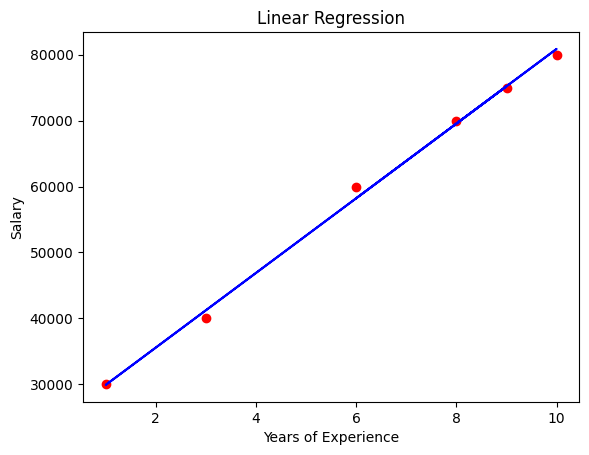

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
data = pd.read_csv("Salary_Data.csv")
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3)

# Train model
reg = LinearRegression()
reg.fit(X_train, y_train)

# Predict test results
y_pred = reg.predict(X_test)

# Print slope & intercept
print("Slope (m):", reg.coef_)
print("Intercept (c):", reg.intercept_)

# Plot
plt.scatter(X_train, y_train, color='red')
plt.plot(X_train, reg.predict(X_train), color='blue')
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression")
plt.show()


In [ ]:
import pandas as pd

df = pd.DataFrame({
    "Level": [1,2,3,4,5,6,7,8,9,10],
    "Salary": [45000,50000,60000,80000,110000,150000,200000,300000,500000,1000000]
})

df.to_csv("Position_Salaries.csv", index=False)
print("Position_Salaries.csv created!")


Position_Salaries.csv created!


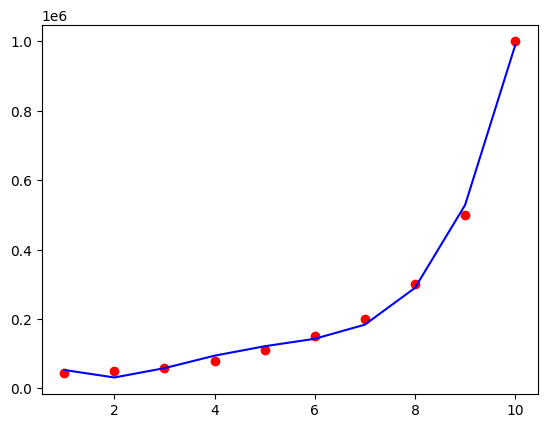

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Load dataset
data = pd.read_csv("Position_Salaries.csv")

# FIXED: Correct X and y
X = data[['Level']].values
y = data['Salary'].values

# Linear Regression
lin = LinearRegression()
lin.fit(X, y)

# Polynomial Regression
poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X)

lin2 = LinearRegression()
lin2.fit(X_poly, y)

# Plot
plt.scatter(X, y, color='red')
plt.plot(X, lin2.predict(X_poly), color='blue')
plt.show()


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np

dataset = pd.read_csv('Position_Salaries.csv')

# FIXED: Automatically use last column as target
X = dataset.iloc[:, :-1].values   # features
y = dataset.iloc[:, -1].values    # salary

poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

level_to_predict = np.array([[6.5]])
predicted_salary = model.predict(poly.transform(level_to_predict))

print(predicted_salary)


[158862.45265155]


In [ ]:
import pandas as pd

data = {
    "Area": [21,15,25,12,20,17],
    "Bedrooms": [3,2,4,2,3,3],
    "Bathrooms": [2,1,3,1,2,2],
    "Location": ["Delhi","Mumbai","Delhi","Bangalore","Mumbai","Bangalore"],
    "Price": [55,48,87,45,69,56]
}

df = pd.DataFrame(data)
df.to_csv('house.csv', index=False)   # Save in current directory

print("house.csv created successfully")


house.csv created successfully


In [ ]:
import pandas as pd                          # For loading and handling data
from sklearn.model_selection import train_test_split   # For splitting data
from sklearn.linear_model import LinearRegression, Lasso, Ridge  # Regression models

house = pd.read_csv('house.csv')             # Load the housing dataset
house = pd.get_dummies(house, drop_first=True)   # Convert categorical columns to numeric

X = house.drop('Price', axis=1)              # Features (inputs)
y = house['Price']                           # Target (output: price)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
# 70% training, 30% testing

linear = LinearRegression().fit(X_train, y_train)   # Train Linear Regression
lasso = Lasso(alpha=50).fit(X_train, y_train)       # Train Lasso Regression (L1)
ridge = Ridge(alpha=50).fit(X_train, y_train)       # Train Ridge Regression (L2)

print(linear.score(X_test, y_test))          # Accuracy of Linear Regression
print(lasso.score(X_test, y_test))           # Accuracy of Lasso Regression
print(ridge.score(X_test, y_test))           # Accuracy of Ridge Regression


-51.404958677686025
-6.712809917355372
0.5162166445536664


In [ ]:
import pandas as pd

data = {
    "Age": [19,35,26,27,32,40],
    "EstimatedSalary": [19000,20000,43000,57000,86000,50000],
    "Gender": ["Male","Female","Male","Female","Male","Female"],
    "Purchased": [0,1,0,1,1,0]
}

df = pd.DataFrame(data)
df.to_csv('Social_Network_Ads.csv', index=False)

print("Social_Network_Ads.csv created!")


Social_Network_Ads.csv created!


In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

# Load data
df = pd.read_csv('Social_Network_Ads.csv')

# Convert Gender to numeric (Male = 1, Female = 0)
df = pd.get_dummies(df, columns=['Gender'], drop_first=True)

# Features (X) and Target (y)
X = df.drop('Purchased', axis=1)
y = df['Purchased']

# Train model
model = LogisticRegression(max_iter=200)
model.fit(X, y)

# Predict for a new person: [Gender_Male, Age, Salary]
print("Prediction for male age 30 salary 87000:", model.predict([[1, 30, 87000]]))

# Print probability of Purchase for all rows
print("Probability of purchase:", model.predict_proba(X)[:, 1])


Prediction for male age 30 salary 87000: [0]
Probability of purchase: [0.19941468 0.35038423 0.4051701  0.62747714 0.7815898  0.63596406]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load the Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split data: 67% training, 33% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)

# Parameters we want GridSearch to test
params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [1, 3, 4, None],
    'splitter': ['best', 'random']
}

# GridSearchCV will try all combinations and select the best model
grid = GridSearchCV(DecisionTreeClassifier(), params, cv=5)
grid.fit(X_train, y_train)

# Predict on the test set
y_pred = grid.predict(X_test)

# Show accuracy and detailed performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.98

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      0.95      0.97        19
           2       0.94      1.00      0.97        15

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# Load MNIST dataset (70,000 images of digits 0–9)
mnist = fetch_openml('mnist_784', version=1)

# Separate features (X) and labels (y)
X, y = mnist['data'], mnist['target']

# Split into training and testing (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Reduce dataset to 2 principal components
pca = PCA(n_components=2)

# Fit PCA on training data and transform
X_train_pca = pca.fit_transform(X_train)

# Transform the test data
X_test_pca = pca.transform(X_test)

# Print variance explained by each component
print("Explained Variance Ratio:", pca.explained_variance_ratio_)


Explained Variance Ratio: [0.09747258 0.07171133]


In [ ]:
import pandas as pd

data = {
    "CustomerID": [1,2,3,4,5,6],
    "Gender": ["Male","Female","Female","Female","Male","Female"],
    "Age": [19,21,20,23,31,22],
    "Annual_Income": [15,15,16,16,17,17],
    "Spending_Score": [39,81,6,77,40,76]
}

df = pd.DataFrame(data)
df.to_csv('mall.csv', index=False)

print("mall.csv created successfully")


mall.csv created successfully


In [ ]:
from sklearn.cluster import KMeans
import pandas as pd

mall = pd.read_csv('mall.csv')
X = mall.iloc[:, [3,4]].values

kmeans = KMeans(n_clusters=5)
y_kmeans = kmeans.fit_predict(X)

from sklearn import datasets
iris = datasets.load_iris()
X2 = pd.DataFrame(iris.data).iloc[:, [1,2]].values  #sepal length sepal width  petal length    petal width

kmeans2 = KMeans(n_clusters=3)
y_pred2 = kmeans2.fit_predict(X2)

print(X[:10])
print(kmeans.cluster_centers_)
print(y_kmeans)



[[15 39]
 [15 81]
 [16  6]
 [16 77]
 [17 40]
 [17 76]]
[[17.  40. ]
 [16.5 76.5]
 [16.   6. ]
 [15.  81. ]
 [15.  39. ]]
[4 3 2 1 0 1]


In [7]:
from sklearn.neural_network import MLPRegressor, MLPClassifier
import numpy as np

# Small sample dataset
X = np.array([[2,9],[1,5],[3,6]], float)
y = np.array([92,86,89], float)

# ANN for Regression
reg = MLPRegressor(hidden_layer_sizes=(3,), activation='logistic', max_iter=700)
reg.fit(X, y)
print("Regressor Output:", reg.predict(X))

# ANN for Classification
clf = MLPClassifier(hidden_layer_sizes=(3,), activation='logistic', max_iter=2000)
clf.fit(X, y)
print("Classifier Output:", clf.predict(X))


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (700) reached and the optimization hasn't converged yet.
  warnings.warn(


Regressor Output: [4.94396492 4.78082881 4.93290065]
Classifier Output: [92. 86. 89.]


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
